In [1]:
import sys
sys.path.append('..')

In [2]:
from glob import glob

import numpy as np
from sklearn.metrics import classification_report
from keras.optimizers import SGD
from keras.models import Sequential
from keras.metrics import BinaryAccuracy
from keras.losses import BinaryCrossentropy
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization

from utils.image_classification.data import (
    show_random_images, train_test_split_by_list,
    create_train_val_df, create_img_data_generator
)
from utils.image_classification.docs import print_cnn_docs
from utils.log import log_loss

# 1. Prepare data

In [3]:
dog_data_path = 'data/dog_cat_dataset/train/dog/*.jpg'
cat_data_path = 'data/dog_cat_dataset/train/cat/*.jpg'

In [4]:
dog_img_paths = glob(dog_data_path)
len(dog_img_paths)

4005

In [5]:
cat_img_paths = glob(cat_data_path)
len(cat_img_paths)

4000

## Visualize data

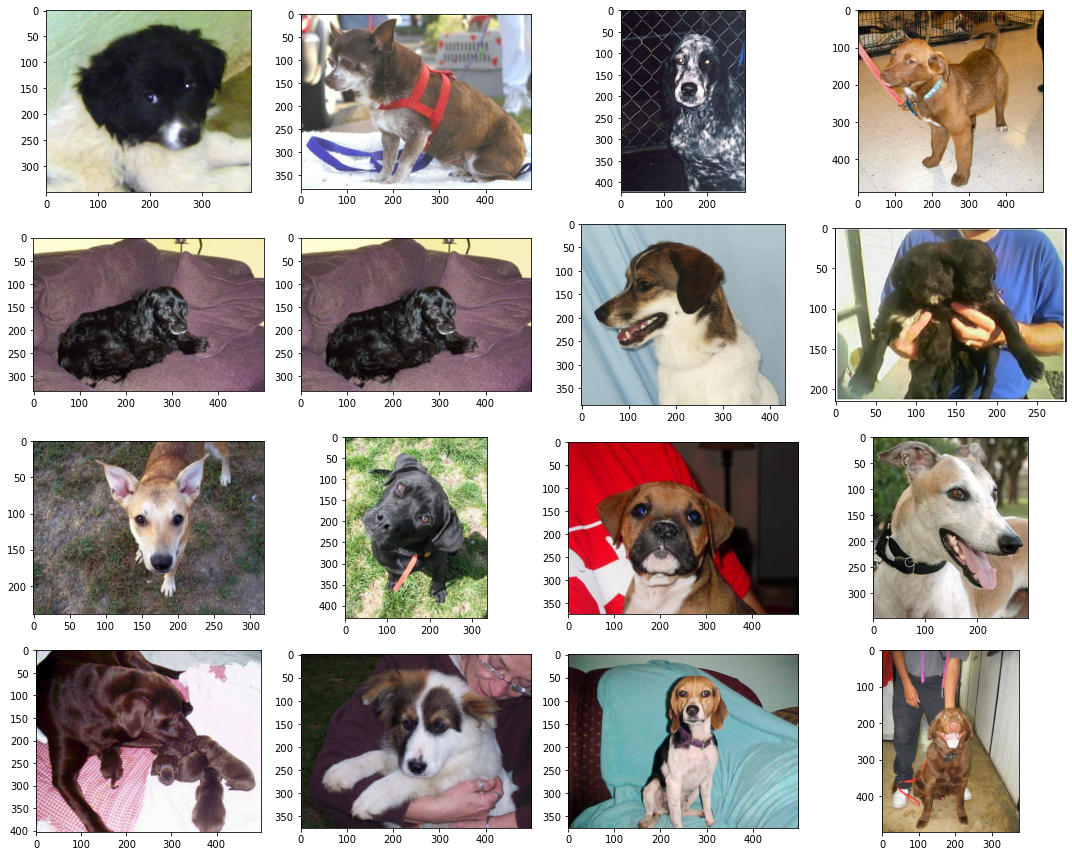

In [6]:
show_random_images(dog_img_paths)

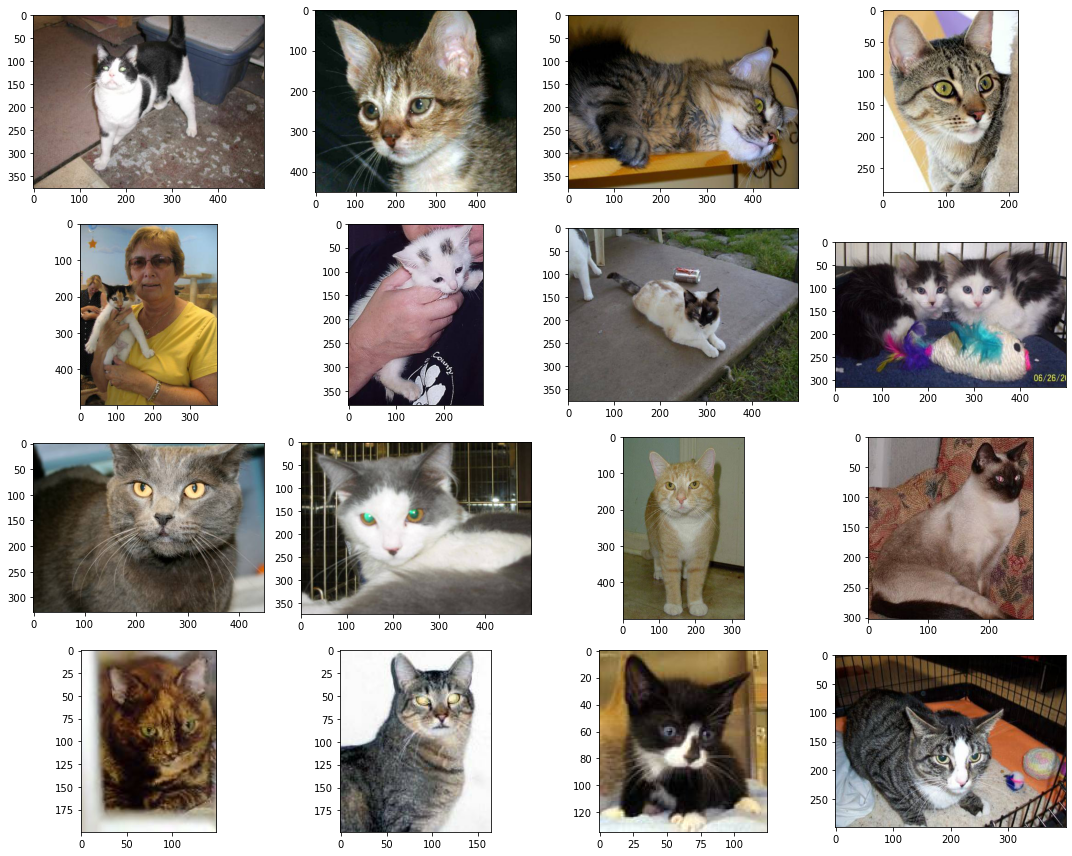

In [7]:
show_random_images(cat_img_paths)

## Split training and validation set

In [8]:
val_percent = 0.2

In [9]:
data_dict = {
    'dog': dog_img_paths,
    'cat': cat_img_paths
}

In [10]:
splitted_data_dict = train_test_split_by_list(data_dict, val_percent)
splitted_data_dict.keys()

dict_keys(['dog', 'cat'])

In [11]:
splitted_data_dict['dog'].keys()

dict_keys(['train_img_paths', 'val_img_paths', 'train_labels', 'val_labels', 'train_labels_idx', 'val_labels_idx'])

In [12]:
splitted_data_dict['cat'].keys()

dict_keys(['train_img_paths', 'val_img_paths', 'train_labels', 'val_labels', 'train_labels_idx', 'val_labels_idx'])

In [13]:
train_df, val_df = create_train_val_df(splitted_data_dict)

In [14]:
train_df

,image_path,label,labels_idx
0,data/dog_cat_dataset/train/dog/dog.2635.jpg,dog,0
1,data/dog_cat_dataset/train/dog/dog.1934.jpg,dog,0
2,data/dog_cat_dataset/train/dog/dog.3134.jpg,dog,0
3,data/dog_cat_dataset/train/dog/dog.3218.jpg,dog,0
4,data/dog_cat_dataset/train/dog/dog.1701.jpg,dog,0
...,...,...,...
6399,data/dog_cat_dataset/train/cat/cat.1688.jpg,cat,1
6400,data/dog_cat_dataset/train/cat/cat.311.jpg,cat,1
6401,data/dog_cat_dataset/train/cat/cat.3589.jpg,cat,1
6402,data/dog_cat_dataset/train/cat/cat.752.jpg,cat,1


In [15]:
val_df

,image_path,label,labels_idx
0,data/dog_cat_dataset/train/dog/dog.770.jpg,dog,0
1,data/dog_cat_dataset/train/dog/dog.3319.jpg,dog,0
2,data/dog_cat_dataset/train/dog/dog.472.jpg,dog,0
3,data/dog_cat_dataset/train/dog/dog.1957.jpg,dog,0
4,data/dog_cat_dataset/train/dog/dog.3986.jpg,dog,0
...,...,...,...
1596,data/dog_cat_dataset/train/cat/cat.2794.jpg,cat,1
1597,data/dog_cat_dataset/train/cat/cat.1375.jpg,cat,1
1598,data/dog_cat_dataset/train/cat/cat.3184.jpg,cat,1
1599,data/dog_cat_dataset/train/cat/cat.2581.jpg,cat,1


## Keras Image Data Generator

In [16]:
IMG_SIZE = 64
BATCH_SIZE = 8

In [17]:
train_data_gen = create_img_data_generator(train_df, IMG_SIZE, BATCH_SIZE)

Found 6404 validated image filenames belonging to 2 classes.


In [18]:
val_data_gen = create_img_data_generator(val_df, IMG_SIZE, BATCH_SIZE * 2)

Found 1601 validated image filenames belonging to 2 classes.


# 2. Build and train model

## Build model

In [19]:
print_cnn_docs()


        1. Conv2D(filters, kernel_size, strides, padding, ...) 

        https://keras.io/api/layers/convolution_layers/convolution2d/ 

        2. BatchNormalization() 

        https://keras.io/api/layers/normalization_layers/batch_normalization/ 

        3. MaxPooling2D(pool_size, strides, padding, ...) 

        https://keras.io/api/layers/pooling_layers/max_pooling2d/ 

        4. Flatten() 

        https://keras.io/api/layers/reshaping_layers/flatten/ 

        5. Dense(units, activation, ...) 

        https://keras.io/api/layers/core_layers/dense/ 

        6. Dropout(rate) 

        https://keras.io/api/layers/regularization_layers/dropout/ 

    


In [20]:
model = Sequential([
    Conv2D(8, 3, 1, 'same', activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    Conv2D(8, 3, 1, 'same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(16, 3, 1, 'same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(32, 3, 1, 'same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, 3, 1, 'same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, 3, 1, 'same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, 'relu'),
    Dropout(rate=0.3),
    Dense(1, 'sigmoid')
])

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 64, 64, 8)         224       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 64, 64, 8)         584       
_________________________________________________________________
batch_normalization (BatchNo (None, 64, 64, 8)         32        
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 32, 32, 8)         0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 32, 32, 16)        1168      
_________________________________________________________________
batch_normalization_1 (Batch (None, 32, 32, 16)        64        
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 16, 16, 16)        0

2023-07-22 22:51:21.275017: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Compile model

In [21]:
bce_loss = BinaryCrossentropy()

In [22]:
opt = SGD(learning_rate=0.001)

In [23]:
model.compile(loss=bce_loss, optimizer=opt, metrics=[BinaryAccuracy()])

In [24]:
NUM_EPOCH = 20

## Train model

In [25]:
history = model.fit(
    x=train_data_gen,
    epochs=NUM_EPOCH,
    validation_data=val_data_gen,
    shuffle=True
)

2023-07-22 22:51:21.462365: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)


Epoch 1/20
801/801 [==============================] - 35s 43ms/step - loss: 0.8254 - binary_accuracy: 0.5542 - val_loss: 0.6324 - val_binary_accuracy: 0.6390
Epoch 2/20
801/801 [==============================] - 33s 41ms/step - loss: 0.6801 - binary_accuracy: 0.6185 - val_loss: 0.6965 - val_binary_accuracy: 0.5978
Epoch 3/20
801/801 [==============================] - 30s 37ms/step - loss: 0.6192 - binary_accuracy: 0.6550 - val_loss: 0.6258 - val_binary_accuracy: 0.6552
Epoch 4/20
801/801 [==============================] - 33s 41ms/step - loss: 0.5748 - binary_accuracy: 0.6967 - val_loss: 0.5779 - val_binary_accuracy: 0.7064
Epoch 5/20
801/801 [==============================] - 31s 39ms/step - loss: 0.5592 - binary_accuracy: 0.7037 - val_loss: 0.5808 - val_binary_accuracy: 0.6952
Epoch 6/20
801/801 [==============================] - 31s 39ms/step - loss: 0.5303 - binary_accuracy: 0.7351 - val_loss: 0.6005 - val_binary_accuracy: 0.6883
Epoch 7/20
801/801 [==============================] 

# 3. Evaluate model

In [26]:
history.history.keys()

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])

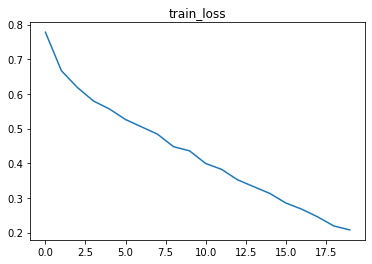

In [27]:
log_loss(range(NUM_EPOCH), history.history['loss'], 'train_loss')

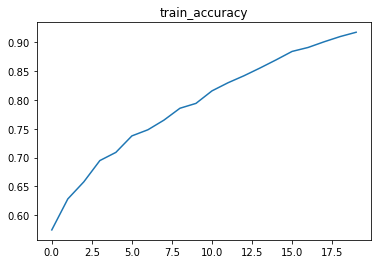

In [28]:
log_loss(range(NUM_EPOCH), history.history['binary_accuracy'], 'train_accuracy')

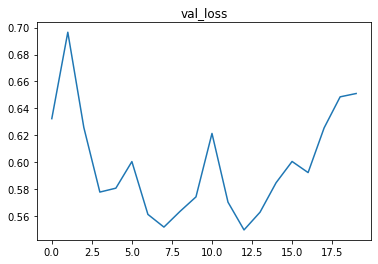

In [29]:
log_loss(range(NUM_EPOCH), history.history['val_loss'], 'val_loss')

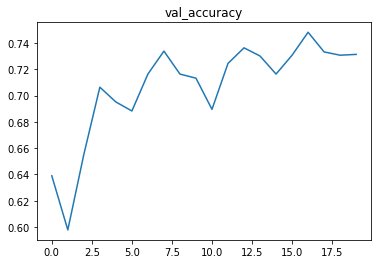

In [30]:
log_loss(range(NUM_EPOCH), history.history['val_binary_accuracy'], 'val_accuracy')

# 4. Predict new data

In [31]:
pred_prob = model.predict(val_data_gen)
pred_prob

array([[0.2525655 ],
       [0.42602152],
       [0.88961625],
       ...,
       [0.04730991],
       [0.00405002],
       [0.63911325]], dtype=float32)

In [32]:
CONFIDENCE_THRESHOLD = 0.5

In [33]:
y_pred = np.where(pred_prob > CONFIDENCE_THRESHOLD, 1, 0).squeeze()
y_pred

array([0, 0, 1, ..., 0, 0, 1])

In [34]:
y_pred.shape

(1601,)

In [35]:
y_true = val_df['labels_idx']
y_true.shape

(1601,)

In [36]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.50      0.50       801
           1       0.50      0.50      0.50       800

    accuracy                           0.50      1601
   macro avg       0.50      0.50      0.50      1601
weighted avg       0.50      0.50      0.50      1601

